In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px

In [2]:
df = pd.read_csv("/content/Books_Data_Clean.csv")

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [9]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,535.926660,1994.730426,4.012230,94817.793855,1832.644985,841.360638,4.844311,613.314172,9744.482656
std,308.769358,23.204719,0.246492,31473.890412,3947.885096,2279.579848,3.561712,369.628663,15350.021050
min,0.000000,1901.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,271.000000,1989.000000,3.860000,70701.000000,366.300000,0.000000,1.990000,291.000000,570.000000
50%,535.000000,2003.000000,4.030000,89204.000000,792.000000,273.240000,3.990000,596.000000,3942.000000
75%,802.000000,2010.000000,4.180000,113400.000000,1470.260000,714.756000,6.990000,933.000000,5427.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [5]:
df.isna().sum()

,0
index,0
Publishing Year,1
Book Name,23
Author,0
language_code,53
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [6]:
df.isnull().sum()

,0
index,0
Publishing Year,1
Book Name,23
Author,0
language_code,53
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df[df["Publishing Year"] > 1900]

In [15]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,0
Author,0
language_code,47
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [14]:
df = df.dropna(subset = "Book Name")

In [16]:
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


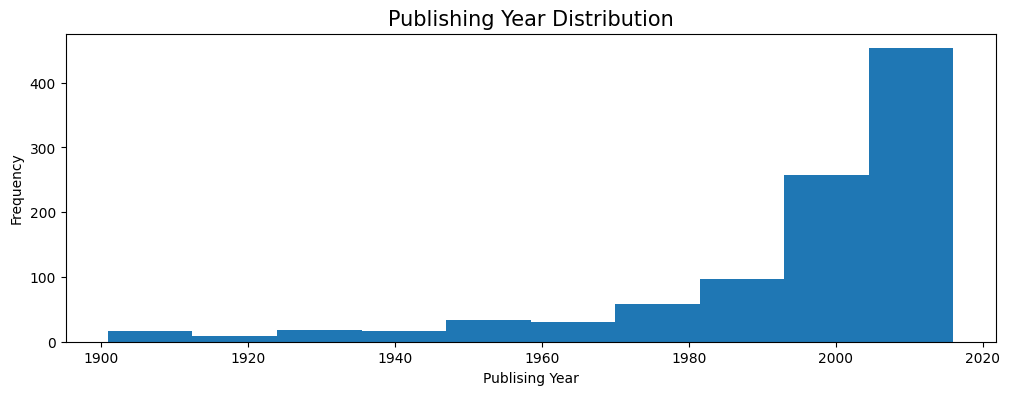

In [22]:
plt.figure(figsize = (12 , 4))
plt.hist(df["Publishing Year"])
plt.xlabel("Publising Year")
plt.ylabel("Frequency")
plt.title("Publishing Year Distribution" , fontsize = 15)
plt.show()

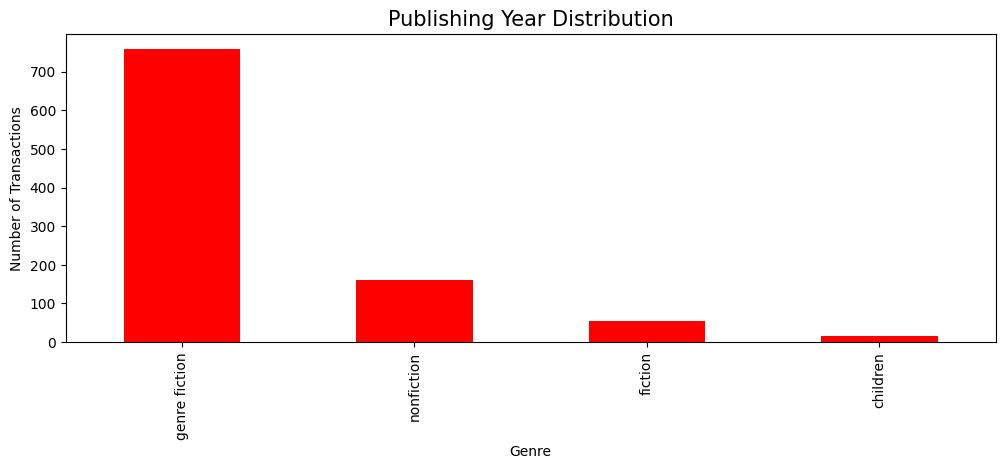

In [24]:
plt.figure(figsize = (12 , 4))
df["genre"].value_counts().plot(kind = 'bar', color = 'Red')
plt.xlabel("Genre")
plt.ylabel("Number of Transactions")
plt.title("Publishing Year Distribution" , fontsize = 15)
plt.show()

In [31]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False ).head()

,Book_average_rating
Author,
Bill Watterson,4.650
"Bill Watterson, G.B. Trudeau",4.610
J.R.R. Tolkien,4.590
George R.R. Martin,4.560
Sarah J. Maas,4.526


In [32]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

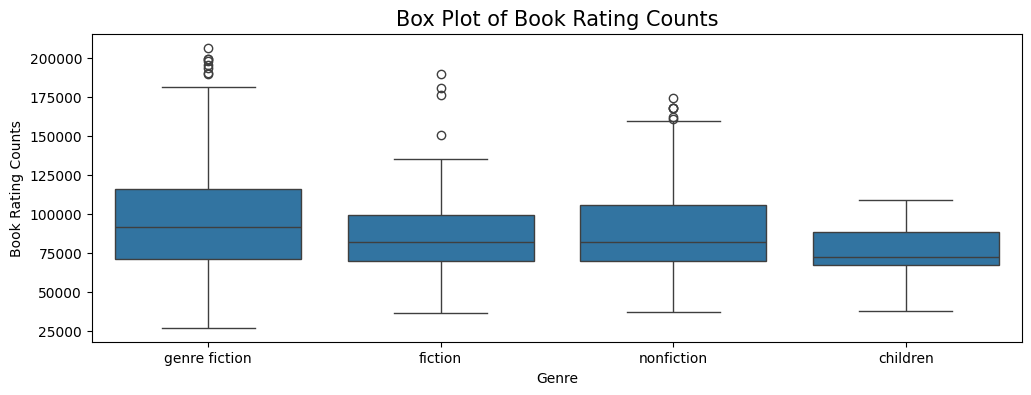

In [34]:
plt.figure(figsize = (12 , 4))
sns.boxplot( x = "genre" , y = "Book_ratings_count" , data = df)
plt.xlabel("Genre")
plt.ylabel("Book Rating Counts")
plt.title("Box Plot of Book Rating Counts" , fontsize = 15)
plt.show()

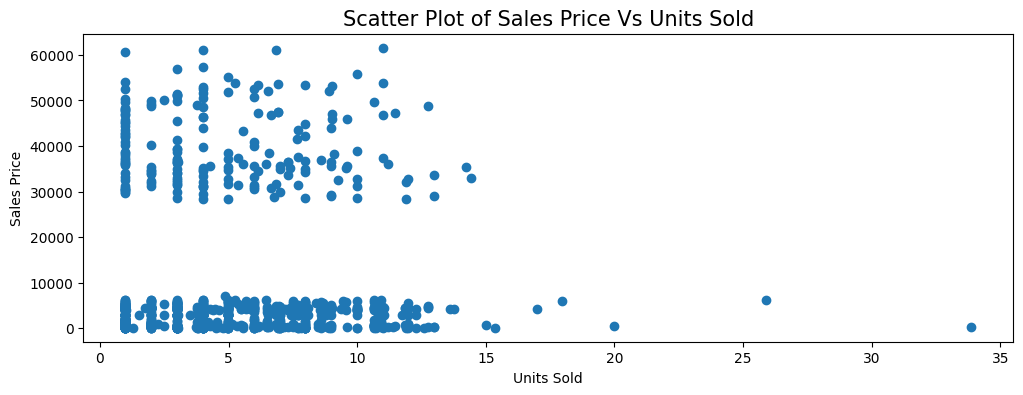

In [36]:
plt.figure(figsize = (12 , 4))
plt.scatter(df["sale price"] , df["units sold"])
plt.xlabel("Units Sold")
plt.ylabel("Sales Price")
plt.title("Scatter Plot of Sales Price Vs Units Sold" , fontsize = 15)
plt.show()

In [42]:
Language_Counts = df["language_code"].value_counts()
#.sort_values(ascending = True)

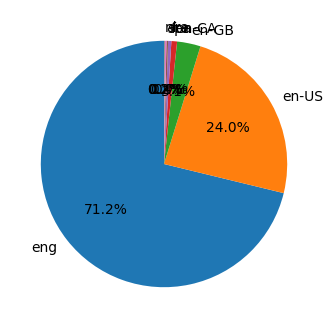

In [46]:
plt.figure(figsize = (12 , 4))
plt.pie(Language_Counts , labels = Language_Counts.index , autopct = "%1.1f%%" , startangle = 90)
plt.show()

In [49]:
df.groupby('Publisher ')["publisher revenue"].sum().sort_values(ascending = False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


In [55]:
df.groupby('Author_Rating')['Book_ratings_count'].mean().sort_values(ascending = False)

,Book_ratings_count
Author_Rating,
Intermediate,101400.272569
Famous,98295.250000
Novice,87318.464286
Excellent,83804.800595


In [57]:
df.groupby('language_code').size()

,0
language_code,
ara,2
en-CA,7
en-GB,29
en-US,226
eng,670
fre,4
nl,1
spa,2


In [58]:
df["language_code"].value_counts()

,count
language_code,
eng,670
en-US,226
en-GB,29
en-CA,7
fre,4
spa,2
ara,2
nl,1


In [60]:
df.groupby('Author_Rating')["Book_average_rating"].max()

,Book_average_rating
Author_Rating,
Excellent,4.39
Famous,4.77
Intermediate,4.38
Novice,3.49


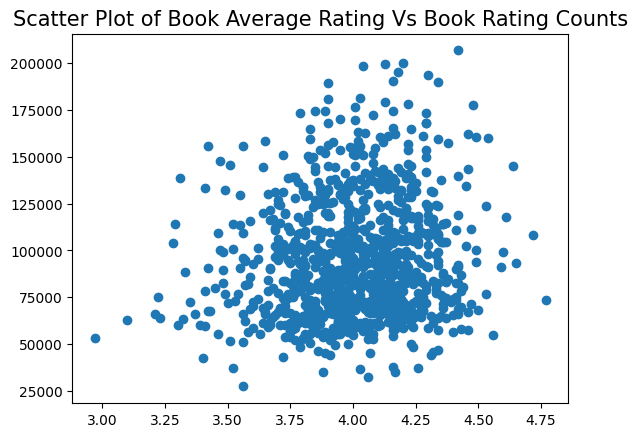

In [63]:
plt.scatter(df["Book_average_rating"] , df["Book_ratings_count"])
plt.title("Scatter Plot of Book Average Rating Vs Book Rating Counts" , fontsize = 15)
plt.show()

In [65]:
Gross_Sales_Author = df.groupby('Author')["gross sales"].sum().sort_values(ascending = False).head()

<Axes: xlabel='Author'>

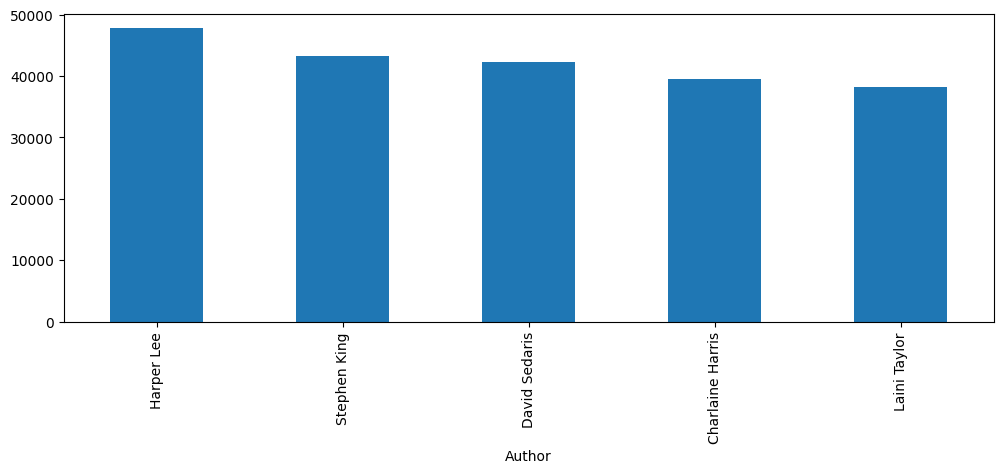

In [67]:
plt.figure(figsize = (12 , 4))
Gross_Sales_Author.plot(kind = 'bar')

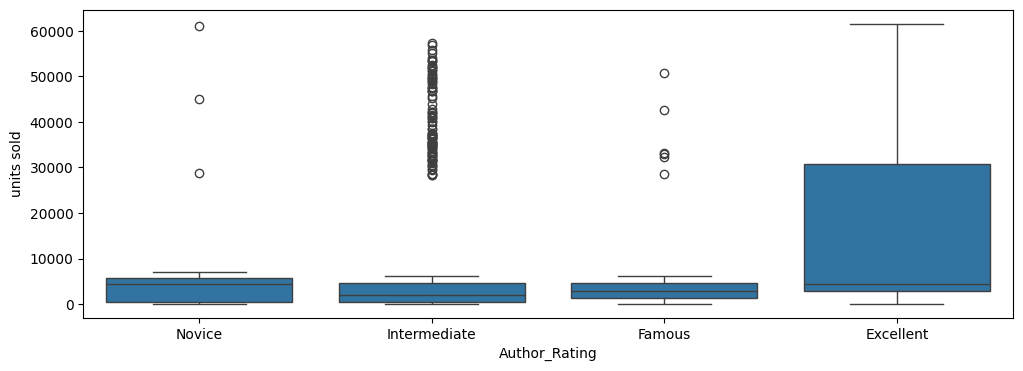

In [71]:
plt.figure(figsize = (12 , 4))
sns.boxplot( x= "Author_Rating" , y = "units sold" , data = df)
plt.show()

In [68]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

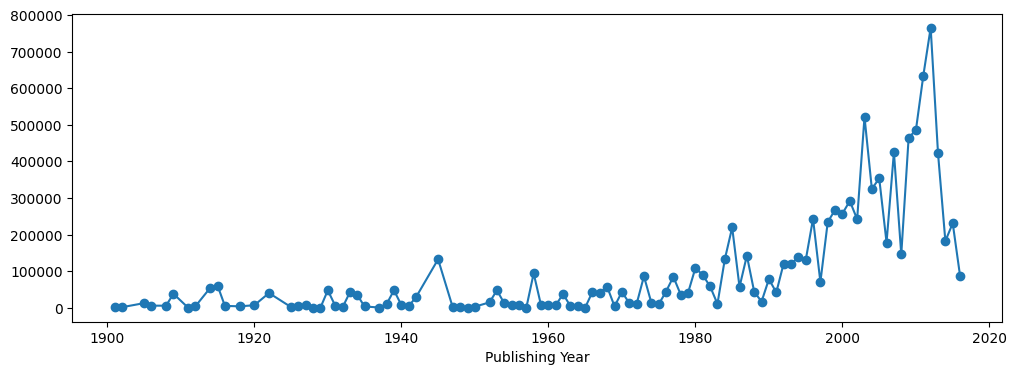

In [72]:
plt.figure(figsize = (12 , 4))
df.groupby('Publishing Year')["units sold"].sum().plot(kind = 'line' , marker = 'o')
plt.show()